In [1]:
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pyart
from netCDF4 import Dataset
from datetime import datetime, timedelta


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
ncfile = Dataset('/glade/derecho/scratch/mawilson/FOG_WPS/run_wps_tblmtn/geo_em.d01.nc')
ncfile2 = Dataset('/glade/derecho/scratch/mawilson/FOG_WPS/run_wps_tblmtn/geo_em.d02.nc')

In [3]:
lon = ncfile.variables['CLONG'][:]
lat = ncfile.variables['CLAT'][:]
hgt = ncfile.variables['HGT_M'][:]

lon2 = ncfile2.variables['CLONG'][:]
lat2 = ncfile2.variables['CLAT'][:]
hgt2 = ncfile2.variables['HGT_M'][:]
#print(ncfile2.variables)

In [4]:
dt = datetime(2021,6,4,10)
duration=1
#Let's build a network of ~20 stations centered on KCVG and KLUK
#First, add the indicies for KCVG and KLUK

st_id = ['KCVG','KLUK','KI69','KI67','KI68','KOXD','KHLB','KIMS','KILN','KMWO','KFGX']

st_xind = [370,377,374,394,417,421,403,338,414,424,315]

st_yind = [459,481,499,450,495,449,408,390,536,483,540] 

#Elevation (IN FEET)
elev = [860,482,843,584,989,1041,975,819,1076,649,912]
#Get verification network locations
Obs_TT = np.zeros((duration,len(elev)))
Obs_R2T = np.zeros((duration,len(elev)))
Obs_ST = np.zeros((duration,len(elev)))
Obs_VT = np.zeros((duration,len(elev)))
Obs_lon = np.zeros((duration,len(elev)))
Obs_lat = np.zeros((duration,len(elev)))
for i in range(1):
    ObsFile = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', skip_header=1)
    ObsFileStr = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', 
                               skip_header=1,usecols=(0),dtype='str')
    #print(time_list[i])
    ind_id = []
    for j in range(len(st_id)):
        #print(ObsFileStr[ObsFileStr==st_id[j]])
        ind_id.append(np.where(ObsFileStr==st_id[j])[0][0])

    Obs_Ti = ObsFile[ind_id,1]
    Obs_R2i = ObsFile[ind_id,5]
    Obs_Si = ObsFile[ind_id,6]
    Obs_Vi = ObsFile[ind_id,11]
    Obs_loni = ObsFile[ind_id,8]
    Obs_lati = ObsFile[ind_id,9]
    Obs_TT[i,:]=Obs_Ti
    Obs_R2T[i,:]=Obs_R2i
    Obs_ST[i,:]=Obs_Si
    Obs_VT[i,:]=Obs_Vi
    Obs_lon[i,:]=Obs_loni
    Obs_lat[i,:]=Obs_lati
Obs_R2T[Obs_R2T>1.05]=np.nan

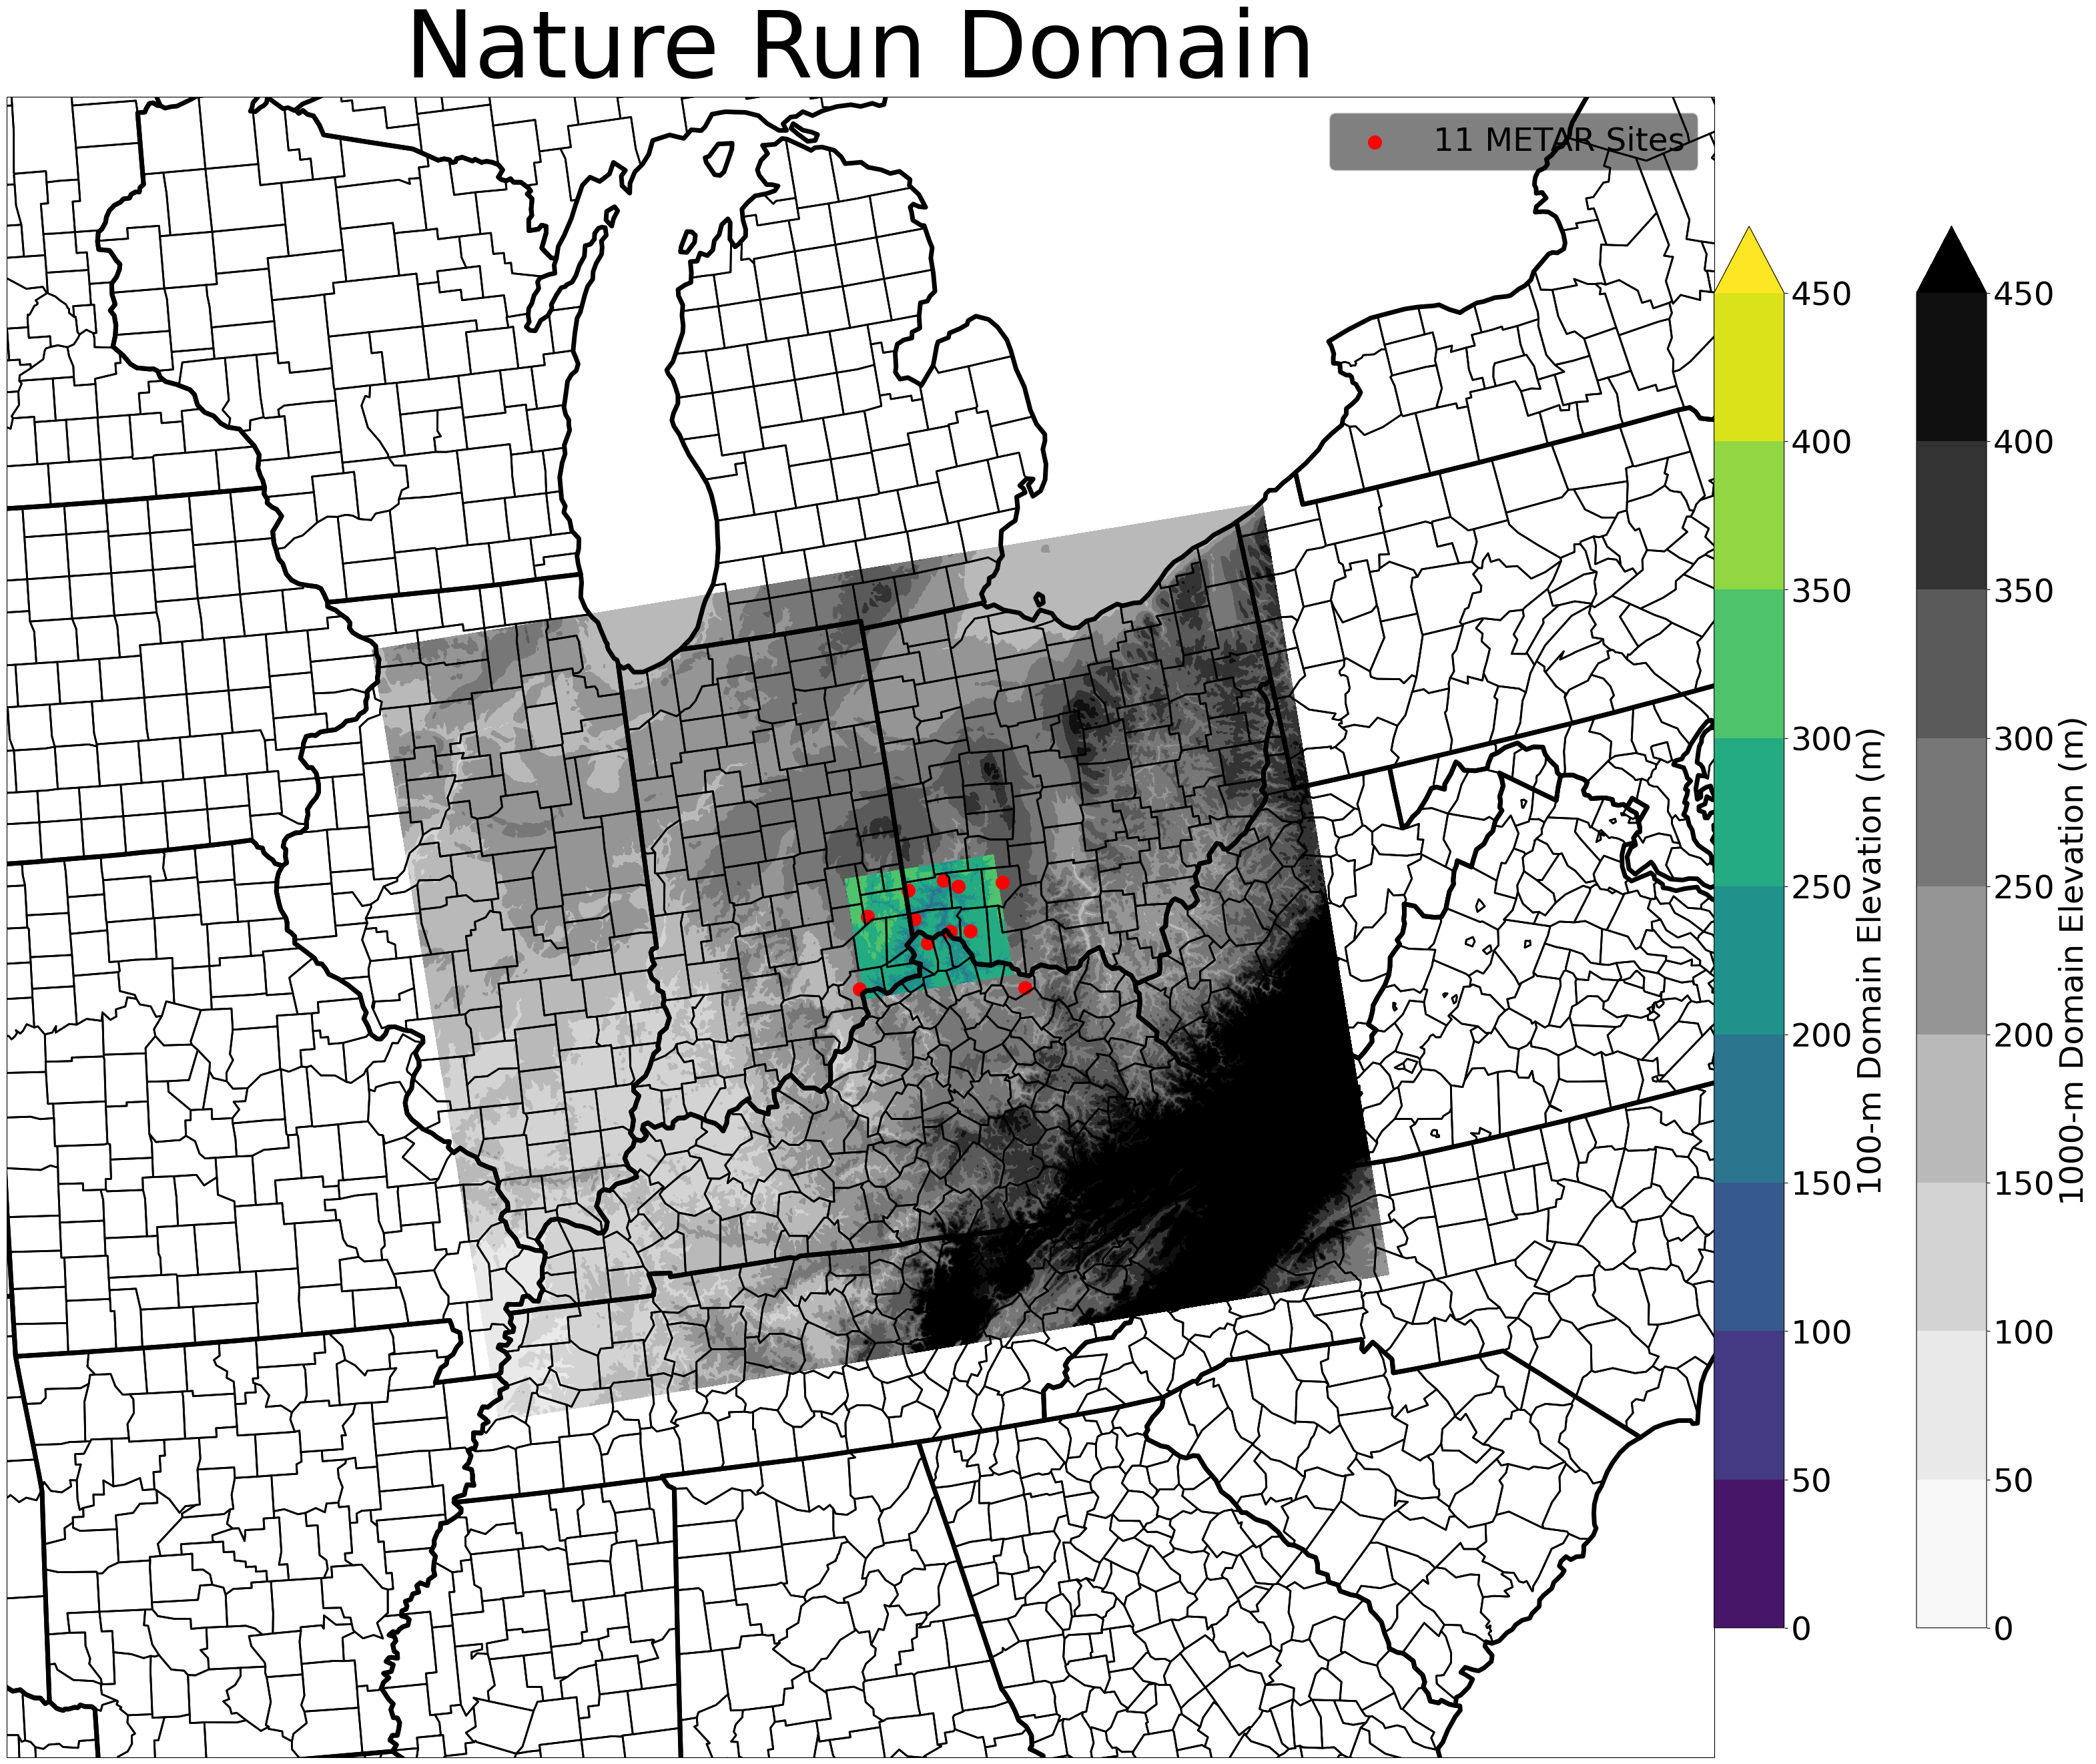

In [5]:
#Make a map to show the domain
lati = 37.15
loni = -84.00

# lat = 39.4
# lon = -101.80
cenlat1 = float(lati)
cenlon1 = float(loni)

LL1 = (cenlon1-10.,cenlat1-4.0,ccrs.PlateCarree())
UR1 = (cenlon1+6.,cenlat1+8.0,ccrs.PlateCarree())

#Set up our map projection

crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

#Read in files for state and county boundaries
fname = 'cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

# Make the plot
fig=plt.figure(1,figsize=(30, 30))
ax = plt.subplot(111,projection=crs)
plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

ax.add_feature(counties, edgecolor = 'k', linewidth = 2.0, zorder=20)
ax.add_feature(states, edgecolor = 'k', linewidth = 5.0, zorder=20)

ax.set_extent([LL1[0],UR1[0],LL1[1],UR1[1]])

#Outer domain
cb = plt.contourf(lon[0,:,:], lat[0,:,:], hgt[0,:,:], np.arange(0,500,50), cmap=plt.cm.Greys, transform=ccrs.PlateCarree(), extend='max')

#Inner domain
cn = plt.contourf(lon2[0,:,:], lat2[0,:,:], hgt2[0,:,:], np.arange(0,500,50), cmap=plt.cm.viridis, transform=ccrs.PlateCarree(), extend='max')

plt.scatter(Obs_lon[0,:], Obs_lat[0,:],s=200, c='r',transform=ccrs.PlateCarree(),label='11 METAR Sites')

cg = plt.colorbar(cb, shrink = .7, pad = 0.06, fraction=0.046)
cg.ax.tick_params(labelsize=35)
cg.set_label("1000-m Domain Elevation (m)",size = 35)

cb = plt.colorbar(cn, shrink = .7, pad = 0.00,fraction=0.046)
cb.ax.tick_params(labelsize=35)
cb.set_label("100-m Domain Elevation (m)",size = 35)

plt.title('Nature Run Domain',size=100)

plt.legend(fontsize=35,facecolor='gray',framealpha=1)

plt.savefig('NatureRunDomain_smaller.png', bbox_inches='tight')

In [6]:
print(np.max(hgt))
print(np.min(hgt))

1813.7333
67.70732


In [7]:
ncfile3 = Dataset('/glade/derecho/scratch/mawilson/FOG_WPS/run_wps_tblmtn/FILE:2022-09-15_00')

FileNotFoundError: [Errno 2] No such file or directory: '/glade/derecho/scratch/mawilson/FOG_WPS/run_wps_tblmtn/FILE:2022-09-15_00'